## Подготовка данных

### Импорты

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.svm import SVR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Загрузка данных

In [ ]:
data = pd.read_csv('processed_data.csv')
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Columns: 195 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(88)
memory usage: 1.4 MB


## Подготовка к обучению данных

In [ ]:
df = data.copy()

In [66]:
X = df.drop(columns='IC50, mM')
y = np.log(df['IC50, mM'])

# Разделяем данных на признаки и целевой столбец

### Стандартизация

In [67]:
scales = StandardScaler()
X_scaled = scales.fit_transform(X)

# Проводим стандартизацию признаков

### Понижение размерности

#### PCA

In [68]:
# pca = PCA(n_components=0.90)
# X_pca = pca.fit_transform(X_scaled)

# PCA не подходит, т.к. это линейный метод понижения размерности,
# а по эксперентам далее, я понял, что данные нелинейно заввисимы, поэтому это ухудшает качество модели

#### SelectBest

In [69]:
# Отбор 50 лучших признаков по mutual_info
selector = SelectKBest(score_func=mutual_info_regression, k=50)
X_selected = selector.fit_transform(X_scaled, y)
selected_feature_names = X.columns[selector.get_support()]

### Разделение данных для обучения

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Разделяем данные на обучающую и тестовую выборки

### Подбор гиперпараметров для модели

In [ ]:
models = {
    "LinearRegression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}),
    "Lasso": (Lasso(max_iter=10000), {"alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]}),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, 15],
            "min_samples_split": [2, 5]
        }
    ),
    "XGBoost": (
        XGBRegressor(random_state=42, verbosity=0),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.01, 0.1, 0.3],
            "subsample": [0.8, 1.0]
        }
    )
}
# Возьмем пять моделей, обычную линейную регрессию, регуляризацию Ridge и Lasso, RF, XGBoost и их разные гиперпараметры для подбора

In [ ]:
%%time

results = []

# Обучение и сравнение моделей
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Test MSE": mean_squared_error(y_test, y_pred),
        "Test R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

CPU times: user 11.9 s, sys: 846 ms, total: 12.8 s
Wall time: 8min 39s


,Model,Best Params,Test MSE,Test R2
0,LinearRegression,{},2.028948,0.477307
1,Ridge,{'alpha': 1.0},2.059004,0.469564
2,Lasso,{'alpha': 0.1},2.148345,0.446549
3,RandomForest,"{'max_depth': 15, 'min_samples_split': 2, 'n_e...",0.099825,0.974283
4,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.054830,0.985875


## Обучение моделей ML

### Линейная регрессия

In [71]:
# Создаем модель линейной регрессии
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

y_lin_reg_pred = lin_reg.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_lin_reg_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_lin_reg_pred))
print('R2 score:', r2_score(y_test, y_lin_reg_pred))

Mean Absolute Error: 1.1076548006724565
Mean Squared Error: 2.038179393313383
R2 score: 0.4749291265851979


### Ridge

In [72]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

y_ridge_pred = ridge.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_ridge_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_ridge_pred))
print('R2 score:', r2_score(y_test, y_ridge_pred))

Mean Absolute Error: 1.1245754395660497
Mean Squared Error: 2.0870754046035525
R2 score: 0.46233265375319066


### Lasso

In [73]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

y_lasso_pred = lasso.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_lasso_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_lasso_pred))
print('R2 score:', r2_score(y_test, y_lasso_pred))

Mean Absolute Error: 1.138073381971443
Mean Squared Error: 2.1142836252459594
R2 score: 0.45532333738798747


### RandomForest

In [74]:
rf = RandomForestRegressor(max_depth=10, min_samples_split = 2, n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_rf_pred = rf.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_rf_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_rf_pred))
print('R2 score:', r2_score(y_test, y_rf_pred))

Mean Absolute Error: 0.1526711539090129
Mean Squared Error: 0.09986461897649945
R2 score: 0.974273117037071


### XGBoost

In [75]:
xgb =  XGBRegressor(learning_rate =  0.1, max_depth = 3, n_estimators=200, subsample=0.8, random_state=42, verbosity=0)

xgb.fit(X_train, y_train)

y_xgb_pred = xgb.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_xgb_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_xgb_pred))
print('R2 score:', r2_score(y_test, y_xgb_pred))

Mean Absolute Error: 0.1338863348895919
Mean Squared Error: 0.050173600759950386
R2 score: 0.9870743976414337


## Вывод

- Линейные модели такие как LinearRegression, Ridge, Lasso объясняют от 46-47 % дисперсии. Результат умеренный, но это связанно с тем, что они плохо работают с нелинейными признаками ( НО когда было PCA, результат был 20-21).

- Random Forest обеспечивает хорошее качество, деревья устойчивы к шумам и легко обучаются.

- XHBoost лучше всего подходит для применения, он немного лучше по R2, а также в 2 раза лучше по MSE, чем RF

XGBoost почти полностью объясняет данные и может быть использован в продакшене

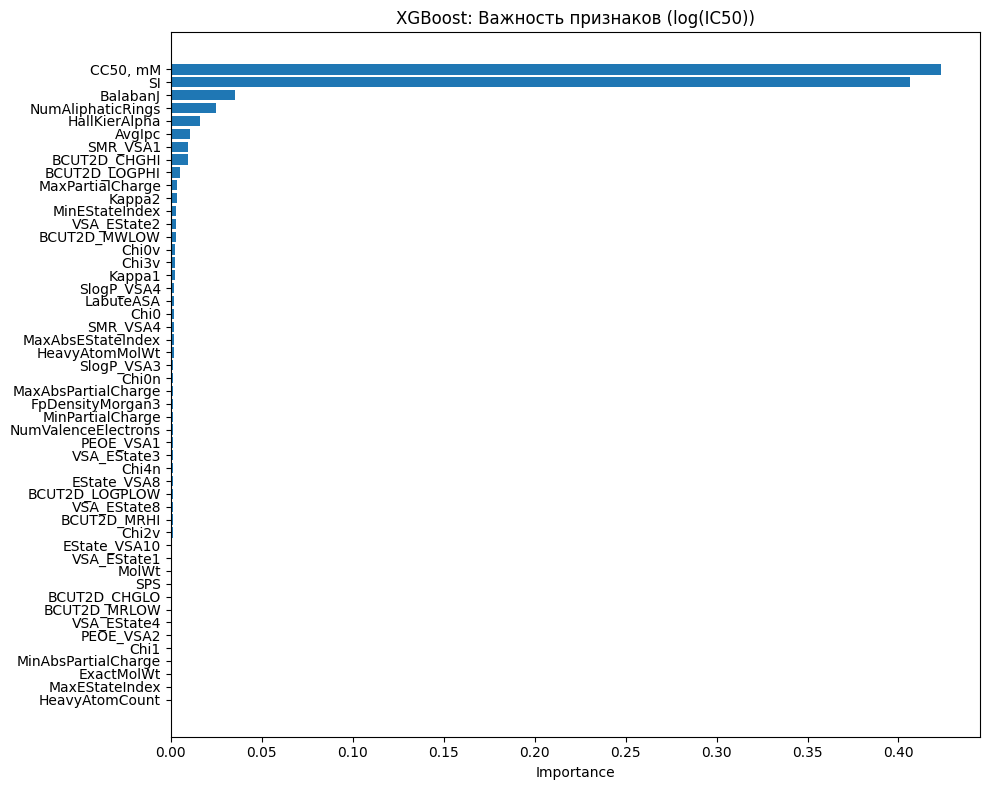

In [ ]:
# Построение графика важности признаков
importances = xgb.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost: Важность признаков (log(IC50))")
plt.tight_layout()
plt.show()